# 18.C21 Problem Set 4 Solutions



## Problem 1 (5+5+5 points) 

Suppose we have a quadrature routine that can compute the following integral for any desired $x$ to high accuracy (more than 10 digits):
$$
F(x) = \int_0^x f(t) dt \, ,
$$
say for $f(t) = e^{t + \sin t}$.  For example, you could use your Clenshaw–Curtis routine from pset 3 with sufficiently many points ($n=100$ should be enough in this problem), or you could use the `QuadGK.quadgk(f, 0, x, rtol=1e-12)[1]` adaptive quadrature routine from the QuadGK.jl package in Julia, or `scipy.integrate.quad(f, 0, x, epsabs=0.0, epsrel=1e-12)[0]` in Python.

Now, however, we want to compute the *inverse* of this function: we want to compute $x = F^{-1}(y)$, i.e. find the $x$ such that $F(x) = y$ for a given $y \ge 0$.  (This is uniquely defined because $f(t) > 0$ implies that $F(x)$ is monotonic.)

**(a)** Outline Newton algorithm to compute $F^{-1}(y)$.   A good initial guess isn't strictly necessary because the function is monotonic, but you can make a reasonable estimate simply approximating $f(t) \approx e^t$, which is accurate for large $t$, yielding an initial guess $x \approx {}$ ____________.  You can terminate the Newton steps when $|\delta x| \le 10^{-10} |x|$.

**(b)** Implement your algorithm, and make a plot of $F^{-1}(y)$ vs. $y$ for $y \in [0,10^3]$.  Also plot your initial guess for comparison.  Also plot the number of Newton steps vs. $y$.

**(c)** This is all rather slow if we want to evaluate $F^{-1}(y)$ zillions of times.  Speed it up by approximating $F^{-1}(y)$ on $y \in [0,10^3]$ by a polynomial interpolated at Chebyshev points similar to pset 2.  What degree polynomial do you need to get a maximum relative error $< 10^{-5}$ at 1000 equispaced points on this interval (excluding $x=0$ where the function is zero)?

### Solution

**(a)** The Newton algorithm is simply to solve $F(x) = y$ for $x$ by the usual iteration $\boxed{x_{k+1} = x_k - F'(x_k)^{-1} (F(x) - y)}$, where the only new ingredient is that, by the fundamental theorem of calculus, $\boxed{F'(x) = f(x)}$.   If, as suggested, we estimate the integral by $y = F(x) \approx \int_0^x e^t dt = e^x - 1$, this corresponds to the the initial guess $\boxed{x_0 \approx \log(1 + y)}$ (for which we can furthermore use the `log1p` function in Julia or Numpy to avoid loss of accuracy for small $|y| \ll 1$).

**(b)** Here, we will implement this algorithm.

As suggested, we will use a pre-written quadrature routine, the [QuadGK package](https://github.com/JuliaMath/QuadGK.jl) in Julia to compute the integral $F(x)$ to at least 12 digits.  First, let's implement $F(x)$ and plot it, along with the approximation $e^x - 1$ for comparison.  (Note that, since $f(t) > 0$, its integral $F(x)$ is monotonic, which will make $F^{-1}$ uniquely defined.)

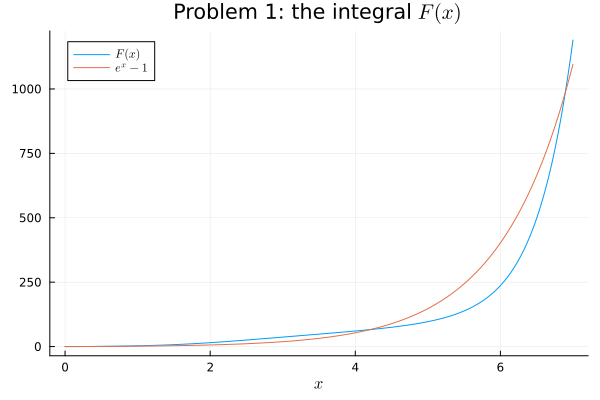

In [1]:
import QuadGK
F(x) = QuadGK.quadgk(t -> exp(t + sin(t)), 0, x, rtol=1e-12, order=13)[1]

using Plots, LaTeXStrings
x = range(0,7,length=1000)
plot(x, F.(x), label=L"F(x)", xlabel=L"x", title=L"Problem 1: the integral $F(x)$")
plot!(x, expm1.(x), label=L"e^x - 1")

Now, we will implement the function.

It's good to check that it is working, by verifying that $F(F^{-1}(y) \approx y$, so we will do this too!

mean(relerr.(F.(x[2:end]), y[2:end])) = 3.6631143751518046e-16


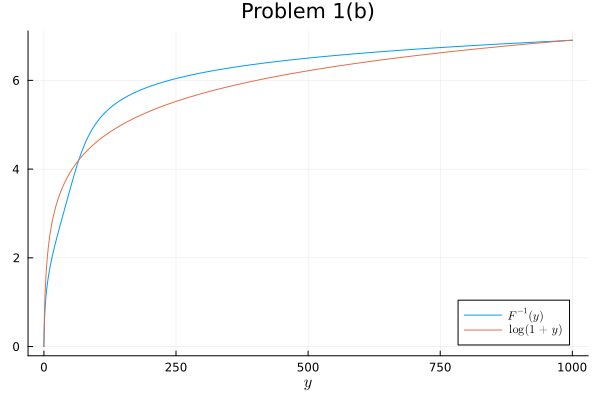

In [2]:
function F⁻¹(y; rtol=1e-12)
    x = log1p(y) # initial guess from F(x) ≈ eˣ - 1
    atol = abs(x) * rtol # absolute stopping tolerance
    while true
        δx = (F(x) - y) / exp(x + sin(x)) # Newton step
        x -= δx
        abs(δx) ≤ atol && return x # terminate
    end
end

# plot the solution as requested
using Plots, LaTeXStrings
y = range(0, 1000, length=1000)
x = F⁻¹.(y)

using Statistics, LinearAlgebra
relerr(u, exact) = norm(u - exact) / norm(exact)
@show mean(relerr.(F.(x[2:end]), y[2:end])) # check mean relative error excluding y=0

plot(y, x, label=L"F^{-1}(y)", xlabel=L"y", title="Problem 1(b)")
plot!(y, log1p.(y), label=L"\log(1 + y)")

We can see from the output above that the average relative error $|F(F^{-1}(y)) - y|/|y|$ is $\approx 3 \times 10^{-16}$ — nearly machine precision (excluding $y=0$ where $F^{-1}(0) = 0$ is exact but the relative error is not defined).  So it looks like it is working!

You can also see that our approximate initial guess is not too terrible, which will help Newton converge quickly.

**(c)** As in pset 2, we'll just use a package to do our Chebyshev interpolation, the [FastChebInterp package](https://github.com/JuliaMath/FastChebInterp.jl) in Julia (and there are somewhat analogous routines in Python).  After some experimentation, we find that we need about **degree ≈ 200** (201 points) to get a maximum relative error of $10^{-5}$.

In [3]:
using FastChebInterp
n = 200 # degree
p = chebinterp(F⁻¹, n, 0, 1000; tol=0)

ChebPoly{1,Float64,Int64} order (200,) polynomial on [0,1000]

Let's check it on our 1000 equispaced points, excluding $y=0$, as suggested:

In [4]:
y = range(0, 1000, length=1001)[2:end] # 1000 equispaced points excluding y=0
maximum(relerr.(p.(y), F⁻¹.(y)))

1.0791570015416231e-5

#### Remark on Problem 1(c):

If we look closely at the relative error of our polynomial approximant $p(y)$, as in the plot below, we'll see that it is largest for small $y \to 0$ where $F^{-1}(y) \to 0$.    This should make intuitive sense: the relative error is $|p(y) - F^{-1}(y)|/F^{-1}(y)|$, and as the denominator goes to zero it becomes more challenging to approximate.

A typical solution to this problem is that, if you are approximating a function that goes to zero (a root) at a known location (like $y=0$), and you want a small relative error near the zero, it is good to use a polynomial that becomes more and more accurate as you approach that point.  And a good choice is simply a **Taylor series** around $y=0$.   But you don't use the Taylor series everywhere, since it becomes inaccurate (or may fail to converge at all) for points far away!  Instead, you **switch between multiple approximations**: say, a Taylor series close to the root, then maybe a Chebyshev polynomial for intermediate values of $y$, and then maybe some other asymptotic approximation for large $y \gg 1$ (like an "asymptotic series" or a "rational approximant").   Approximating transcendental functions *quickly and accurately* is largely a matter of **gluing together different approximations for different inputs**.

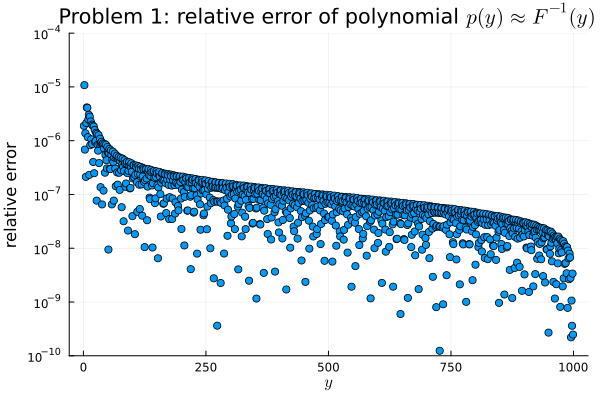

In [5]:
scatter(y, relerr.(p.(y), F⁻¹.(y)), yscale=:log10, ylim=(1e-10, 1e-4), legend=false,
  xlabel=L"y", ylabel="relative error", title=L"Problem 1: relative error of polynomial $p(y) \approx F^{-1}(y)$")

## Problem 2 (5+5 points)

We showed in class that Gaussian elimination without row swaps corresponds to the factorization $A = LU$ of an $n \times n$ matrix $A$.  However, in practice the computer does many row swaps in order to make the pivots as large as possible, leading to a factorization $PA = LU$ where $P$ is a permutation matrix (stored implicitly as just a list of numbers indicating the row ordering) representing all of the row swaps that were required.  In this problem, you will see why the computer swaps rows even when it isn't "necessary" (the pivots aren't zero).

Consider the matrix
$$
A = \begin{pmatrix} 10^{-100} & 1 \\ 1 & 1 \end{pmatrix} \, .
$$
Suppose we want to solve $Ax = b$ for the right-hand side $b = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$.  The *exact* solution is $x = \frac{1}{1 - 10^{-100}} \begin{pmatrix} -1 \\ 1 \end{pmatrix}$.

**(a)** Solve this $Ax=b$ for $x$ using Gaussian elimination by hand, but pretend you are doing standard floating-point arithmetic: round the result of every arithmetic operation to 16 significant digits.  Perform *no row swaps*: they are not strictly required since $10^{-100} \ne 0$.  Show that the resulting approximate solution $\tilde{x}$ is *completely wrong* compared to the exact solution.

**(b)** On a computer, Gaussian elimination uses "partial pivoting": it swaps rows to make the pivot element as big in magnitude as possible (looking at all the entries under each pivot before doing elimination under each column).  Carry out this algorithm by hand on the same $Ax=b$ above, again rounding the result of each arithmetic operation.  (Note that any row swaps must be performed on both the matrix and the right-hand-side.)  Show that you get a *much more accurate answer*.

This simple example helps explain why partial pivoting is crucial to make Gaussian elimination (i.e. LU factorization) robust in floating-point arithmetic.


### Solution

**(a)** If we carry out Gaussian elimination without row swaps, we only need to do one step, using $10^{-100}$ as the first pivot:
$$
\begin{pmatrix} \boxed{10^{-100}} & 1 \\ 1 & 1 \end{pmatrix}
\stackrel{r_2 - \color{red}{10^{100}}r_1}{\longrightarrow}
\begin{pmatrix} \boxed{10^{-100}} & 1 \\ 0 & 1 - 10^{100}  \end{pmatrix}
\approx
\begin{pmatrix} \boxed{10^{-100}} & 1 \\ 0 & - 10^{100} \end{pmatrix} = \tilde{U}
$$
where we have rounded $1 - 10^{100} \approx - 10^{100}$, since the $1$ only affects the 100th significant digit — this will be lost in 16-digit floating-point arithmetic!

We also do the same row operation to our right-hand side
$$
\begin{pmatrix} 1 \\ 0 \end{pmatrix}
\stackrel{r_2 - \color{red}{10^{100}}r_1}{\longrightarrow}
\begin{pmatrix} 1 \\ - 10^{100} \end{pmatrix} = c
$$

Now, we solve $\tilde{U} \tilde{x} = c$ by back-substitution to get our approximate solution $\tilde{x}$.  The last row gives $- 10^{100} \tilde{x}_2 = - 10^{100} \implies \tilde{x}_2 = 1$.  The first row gives $10^{-100} \tilde{x}_1 + \tilde{x}_2 = 1 \implies  \tilde{x}_1 = 0$, i.e. we get the "solution"
$$
 \tilde{x} = \boxed{\begin{pmatrix} 0 \\ 1 \end{pmatrix} } \, ,
$$
which is **completely wrong** — it is not even close to our exact solution!   A tiny roundoff error in the 100th significant digit has led to catastrophe: this is a symptom of "numerical instability".

We can also reproduce this in Julia, using the `NoPivot()` option to `lu` to prevent pivoting:

In [6]:
using LinearAlgebra

A = [1e-100 1
     1      1]
b = [1,0]

x̃ = lu(A, NoPivot()) \ b

2-element Vector{Float64}:
 0.0
 1.0

which indeed is the same *completely wrong* answer.

**(b)** Now, let's try it with "partial pivoting" — at each step, we swap rows to make the pivot as big as possible in magnitude.  Here, clearly $1 > 10^{-100}$ so we will start with a row swap to make $1$ the pivot, and then proceed with Gaussian elimination as usual:
$$
\begin{pmatrix} 10^{-100} & 1 \\ 1 & 1 \end{pmatrix}
\stackrel{r_2 \leftrightarrow r_1}{\longrightarrow}
\begin{pmatrix} \boxed{1} & 1 \\ 10^{-100} & 1 \end{pmatrix}
\stackrel{r_2 - \color{red}{10^{-100}}r_1}{\longrightarrow}
\begin{pmatrix} \boxed{1} & 1 \\ 0 & 1 - 10^{-100} \end{pmatrix}
\approx
\begin{pmatrix} \boxed{1} & 1 \\ 0 & 1 \end{pmatrix} = \hat{U}
$$
where we have rounded $1 - 10^{-100} \approx 1$, since the $10^{-100}$ only affects the 100th significant digit — again, this will be lost in 16-digit floating-point arithmetic.

We also do the same row operation to our right-hand side
$$
\begin{pmatrix} 1 \\ 0 \end{pmatrix}
\stackrel{r_2 \leftrightarrow r_1}{\longrightarrow}
\begin{pmatrix} 0 \\ 1 \end{pmatrix}
\stackrel{r_2 - \color{red}{10^{-100}}r_1}{\longrightarrow}
\begin{pmatrix} 0 \\ 1 \end{pmatrix} = \hat{c}
$$

Finally, we solve $\hat{U} \hat{x} = \hat{c}$ to get our *new* approximate solution $\hat{x}$.  The last row gives $\hat{x}_2 = 1$, and the first row gives $\hat{x}_2 + \hat{x}_2 = 0 \implies \hat{x}_1 = -1$, for an approximate solution of:
$$
\hat{x} = \boxed{ \begin{pmatrix} -1 \\ 1 \end{pmatrix} } \, ,
$$
which is **nearly correct**: it only differs from the exact solution in the 100th significant digits!  A tiny roundoff error during the computations led to only a tiny roundoff error in the solution, which we should have hoped for since the condition number of this $A$ matrix is small.  This is a **numerically stable** algorithm.

In [7]:
cond(A) # condition number of A is small — we should hope for an accurate answer

2.6180339887498953

Indeed, partial pivoting is precisely the algorithm that Julia (and other good-quality linear-algebra libraries) employs:

In [8]:
LU = lu(A) # uses partial pivoting by default
x̂ = LU \ b # accurate answer

2-element Vector{Float64}:
 -1.0
  1.0

In [9]:
LU.p # the row permutation used for this LU factorization

2-element Vector{Int64}:
 2
 1

We can see that Julia indeed swapped the rows, and gave the same (accurate) approximate answer as our hand computation.

## Problem 3 (6 points)

In class, when discussing radial basis functions, we introduced the "minimum-norm" solution for a "wide" $m \times n$ matrix $A$ with $n \ge m$.  In this case, assuming that the rows of $A$ are linearly independent, the equation $Ax=b$ has infinitely many solutions $x$.  The **minimum-norm solution** is the solution that minimizes $\Vert x \Vert_2$.   We gave a geometric argument in class why this solutions is exactly:
$$
x = A^T (AA^T)^{-1} b \, .
$$

Suppose that we have the thin QR factorization $A^T = \hat{Q} \hat{R}$ of $A^T$.  Simplify the minimum-norm solution in terms of $\hat{Q}$ and $\hat{R}$, and explain why the relative error in $x$ is then proportional to the condition number of $\hat{R}$.

### Solution

If we plug in $A^T = \hat{Q} \hat{R}$, then $AA^T = (\hat{Q} \hat{R})^T \hat{Q} \hat{R} = \hat{R}^T \hat{R}$, since $\hat{Q}^T \hat{Q} = I$.  And $\hat{R}$ is a square, invertible matrix, so we get:
$$
x = \hat{Q} \hat{R} (\hat{R}^T \hat{R})^{-1} b = \hat{Q} \hat{R} \hat{R}^{-1} (\hat{R}^T)^{-1} b = \boxed{\hat{Q} (\hat{R}^T)^{-1} b} \, ,
$$
which has simplified considerably because of all of the cancellations.

Just as for the least-square problem in class, since $\kappa(\hat{Q}) = 1$, the roundoff errors are dominated by the $(\hat{R}^T)^{-1} b$ computation, i.e. solving a square (and upper-triangular) linear system involving $\hat{R}$.  From class, the relative error growth of solving a linear system is proportional to the condition number $\kappa(\hat{R}) = \kappa(A^T)$.

*Remark*: As mentioned in class, the QR factorization of $A^T$ is equivalent to an "[LQ factorization](https://www.netlib.org/lapack/lug/node41.html)" of $A$.

## Problem 4 (5+5 points)

If $A$ is a diagonalizable $n \times n$ matrix, with eigenvectors as the columns of a matrix $X$ and eigenvalues $\lambda_1, \ldots, \lambda_n$ as the diagonal of a matrix $\Lambda$, then the matrix exponential can *in principle* be computed easily from the diagonalization $A = X \Lambda X^{-1}$ by simply exponentiating the eigenvalues:
$$
e^A = X e^\Lambda X^{-1} =X \begin{pmatrix} e^{\lambda_1} & & \\ & \ddots & \\ & & e^{\lambda_n} \end{pmatrix} X^{-1}  \, .
$$
This is a formula you should have seen in 18.03 or 18.06.  However, this formula is *very inaccurate* if the eigenvector matrix $X$ is ill-conditioned, e.g. if two eigenvectors are nearly parallel (which can happen if two eigenvalues are nearly equal).

Linear-algebra libraries provide more accurate ways to compute $e^A$, as described in the famous paper ["19 dubious ways to compute the exponential of a matrix"](https://www.cs.jhu.edu/~misha/ReadingSeminar/Papers/Moler03.pdf).  In Julia, you can use `exp(A)`, while in Python you can use `scipy.linalg.expm(A)`.

In this problem, you will explore the inaccuracy of the naive formula by making a $2 \times 2$ matrix $A(\theta) = X(\theta) \Lambda(\theta) X(\theta)^{-1}$ with two eigenvalues $\lambda_1 = 1$ and $\lambda_2 = 1 + \theta$ and two eigenvectors at an angle $\theta$, via:
$$
\Lambda(\theta) = \begin{pmatrix} 1 & \\ & 1 + \theta \end{pmatrix}, \qquad X(\theta) = \begin{pmatrix} 1 & \cos \theta \\ 0 & \sin \theta \end{pmatrix} \, .
$$

**(a)** Form the matrix $A(\theta)$ for $\theta = 0.2$ radians, compute its eigenvalues and eigenvectors using `eigen` in Julia (via the LinearAlgebra standard library) or `scipy.linalg.eig` in Python, and use this to compute the matrix exponential $M(\theta) = e^A(\theta)$ by the naive formula above.   Check that it is pretty close to the result $B$ of the built-in matrix exponential function (`exp` in Julia or `scipy.linalg.expm` in Python).

**(b)** Compute the relative error $\Vert M(\theta) - B \Vert / \Vert B \Vert$ where $\Vert \cdots \Vert$ is the `norm` function in Julia or `numpy.linalg.norm` in Python, and plot it on a log–log scale as a function of $\theta$ for $\theta$ from $10^{-14}$ to $\pi/2$.  You should see that as the eigenvectors become more parallel ($\theta \to 0$), the naive result $M(\theta)$ becomes inaccurate (the built-in result $B$ remains accurate, though you need not verify this) due to the ill-conditioning.

### Solution

**(a)**

First, let's define the function $A(\theta)$ from the given formulas, in the most straightforward way (though this itself has problems for small $|\theta|$ as discussed in the *Remark* below):

In [10]:
using LinearAlgebra

X(θ) = [1 cos(θ)
        0 sin(θ)]
Λ(θ) = Diagonal([1, 1+θ])
A = θ -> let X = X(θ); X * Λ(θ) / X; end # compute XΛX⁻¹

#4 (generic function with 1 method)

And, for any matrix $A$, we'll write a `naiveexp(A)` function to naively compute $e^A$ using the diagonalization, just as you might have learned in linear algebra:

In [11]:
function naiveexp(A)
    λ, X = eigen(A) # eigenvalues and eigenvectors
    return X * Diagonal(exp.(λ)) / X # compute X exp(Λ) X⁻¹
end

naiveexp (generic function with 1 method)

As long as $\theta$ is not too small ($X$ is not too ill-conditioned), this works fine:

In [12]:
naiveexp(A(0.2))

2×2 Matrix{Float64}:
 2.71828  2.96895
 0.0      3.32012

In [13]:
exp(A(0.2))

2×2 Matrix{Float64}:
 2.71828  2.96895
 0.0      3.32012

In [14]:
naiveexp(A(0.2)) - exp(A(0.2))

2×2 Matrix{Float64}:
 -4.44089e-16  -1.33227e-15
  0.0           8.88178e-16

They match to quite a few digits!

**(b)** 

Let's compute and plot the error as a function of $\theta$, using the `relerr` function we defined in a previous part (using `norm`):

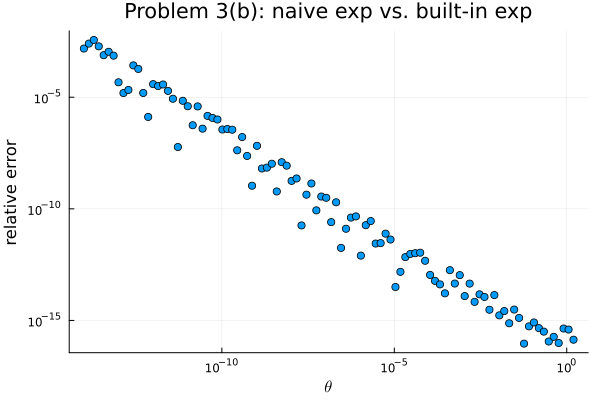

In [15]:
θ = 10 .^ range(-14, log10(pi/2), length=100)

scatter(θ, relerr.(naiveexp.(A.(θ)), exp.(A.(θ))), yscale=:log10, xscale=:log10, legend=false,
     xlabel=L"\theta", ylabel="relative error", title="Problem 3(b): naive exp vs. built-in exp")

### Remark on problem 3b:

We can also avoid catastrophic cancellation if we do things analytically.  In fact, even the computation of $A(\theta)$ itself is isacurate here due to the ill-conditioning of $X(\theta)$.   If we write out the $2 \times 2$ formulas by hand, we can perform subtractions analytically, *before* plugging them in on a computer, in order to avoid catastrophic cancellations.

Since $X(\theta)$ becomes ill-conditioned (singular) as $\theta \to 0$, we'll try a little harder to compute it accurately by doing things analytically and then simplifying to make sure that we don't have catastrophic cancellations for small $\theta$.  Using the usual formula for the inverse of a $2 \times 2$ matrix, we get:
\begin{align}
A(\theta) &= X(\theta) \Lambda(\theta) X(\theta)^{-1} = \begin{pmatrix} 1 & (1+\theta) \cos \theta \\ 0 & (1+\theta)\sin \theta \end{pmatrix} \begin{pmatrix} 1 & \cos \theta \\ 0 & \sin \theta \end{pmatrix}^{-1} \\
&= \frac{1}{\sin \theta}\begin{pmatrix} 1 & (1+\theta) \cos \theta \\ 0 & (1+\theta)\sin \theta \end{pmatrix} \begin{pmatrix} \sin \theta & -\cos \theta \\ 0 & 1 \end{pmatrix} \\
&= \frac{1}{\sin \theta}\begin{pmatrix} \sin\theta & \theta \cos \theta \\ 0 & (1+\theta) \sin \theta  \end{pmatrix} = \begin{pmatrix} 1 & \theta \cot \theta \\ 0 & (1+\theta)   \end{pmatrix}
\end{align}
Note that as $\theta \to 0$, we have $A \to \begin{pmatrix} 1 & 1 \\ 0 & 1 \end{pmatrix}$, which is perhaps the canonical example of a [defective (non-diagonalizable) matrix](https://en.wikipedia.org/wiki/Defective_matrix).   In calculating it this way, note that we computed the subtraction $(1+\theta) \cos \theta - \cos\theta = \theta \cos\theta$ analytically, obtaining an accurate result, whereas if we separately computed $(1+\theta) \cos \theta $ and $\cos \theta$ in floating-point arithmetic and subtracted them, we would incur a catastrophic cancellation error.

(You can easily verify numerically that the above formula matches the naive formula $X \Lambda X^{-1}$ with explicit inversion of $X$, for say $\theta = 0.1$, but that the naive formula becomes increasingly inaccurate for $\theta \to 0$ due to roundoff errors exacerbated by the ill-conditioning of $X$.)

Now, if we do the same thing for the matrix exponential, we get:
\begin{align}
e^{A(\theta)} &= X(\theta) e^{\Lambda(\theta)} X(\theta)^{-1} = e^1 \begin{pmatrix} 1 & e^{\theta} \cos \theta \\ 0 & e^{\theta}\sin \theta \end{pmatrix} \begin{pmatrix} 1 & \cos \theta \\ 0 & \sin \theta \end{pmatrix}^{-1} \\
&= e^1 \frac{1}{\sin \theta}\begin{pmatrix} 1 & e^{\theta} \cos \theta \\ 0 & e^{\theta}\sin \theta \end{pmatrix} \begin{pmatrix} \sin \theta & -\cos \theta \\ 0 & 1 \end{pmatrix} \\
&= e^1 \frac{1}{\sin \theta}\begin{pmatrix} \sin\theta & (e^{\theta}-1) \cos \theta \\ 0 & e^{\theta} \sin \theta  \end{pmatrix} = e^1 \begin{pmatrix} 1 & (e^{\theta}-1) \cot \theta \\ 0 & e^{\theta}   \end{pmatrix}
\end{align}
Here, the potential catastrophic cancellation is clear: it occurs in the $e^{\theta}-1$ factor for $|\theta|\ll 1$.  Fortunately, numerical libraries like Julia and Numpy provide a function `expm1` for precisely this reason: they compute $\text{expm1}(x) = e^x - 1$ accurately for all $x$, avoiding the naive formula for small $|x|$.  So, as long as we use the `expm1` formula, the above equation will be accurate.

You weren't required to do any of this analysis, but it is interesting to plot the errors of the built-in and naive `exp` functions applied to the *accurate* $A(\theta)$, compared to the analytical formula using `expm1`:

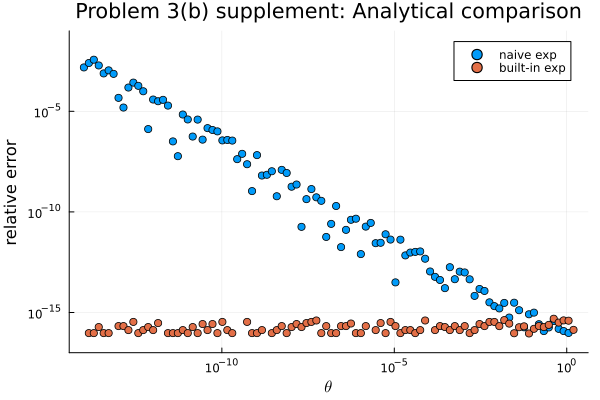

In [16]:
A_accurate(θ) = [1 θ*cot(θ); 0 1+θ] # accurate A(θ) using analytical formula
expA_accurate(θ) = exp(oftype(θ,1)) * [1 expm1(θ)*cot(θ); 0 exp(θ)]

scatter(θ, relerr.(naiveexp.(A_accurate.(θ)), expA_accurate.(θ)), yscale=:log10, xscale=:log10, label="naive exp",
     xlabel=L"\theta", ylabel="relative error", title="Problem 3(b) supplement: Analytical comparison")
scatter!(θ, relerr.(exp.(A_accurate.(θ)), expA_accurate.(θ)), label="built-in exp", ylim=(1e-17, 1e-1))

So, we can see that the built-in `exp` function is indeed accurately computing the matrix exponential, whereas the errors in the naive function are about the same.

*How* the built-in `exp` function works is another story — it is not using diagonalization!  Instead, it uses a method described in ["The Scaling and Squaring Method for the Matrix Exponential Revisited" (Higham, 2005)](https://epubs.siam.org/doi/10.1137/04061101X) and the book [*Functions of Matrices* (Higham, 2008)](https://epubs.siam.org/doi/10.1137/1.9780898717778).  You can find Julia's implementation in the source-code file [`LinearAlgebra/src/dense.jl`](https://github.com/JuliaLang/LinearAlgebra.jl/blob/19ae2d7722a8d9a411007bf5150a8aaa28e60592/src/dense.jl#L782-L918).  The basic idea is to write $e^A = \left(e^{A/2^m}\right)^{2^m}$ for a large enough $m$: the $\left(\cdots\right)^{2^m}$ can be computed by [repeated squaring](https://en.wikipedia.org/wiki/Exponentiation_by_squaring), whereas since $A/2^m$ is a **small matrix** its exponential can be computed in various ways (even a Taylor series would converge rapidly, but in practice a [Padé approximant](https://en.wikipedia.org/wiki/Pad%C3%A9_approximant) is used instead).